<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/example%20RC%20oscillator%20dynamic%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# example: oscilator RC - bad accuracy

Generated training  t_train shape = (1801,), u_train shape = (1801,), y_train_target shape = (1801,)
Generated test  t_test shape = (2002,), u_test shape = (2002,), y_test_target shape = (2002,)
Starting NG-RC Training Phase for Oscillator...
Training data shapes: X_train (1800, 100), Y_train (1800,)
Training completed. W_out shape: (100,)
Starting NG-RC Prediction Phase for Oscillator...
Prediction completed. Y_pred shape: (2002,)
Test RMSE: 0.104925


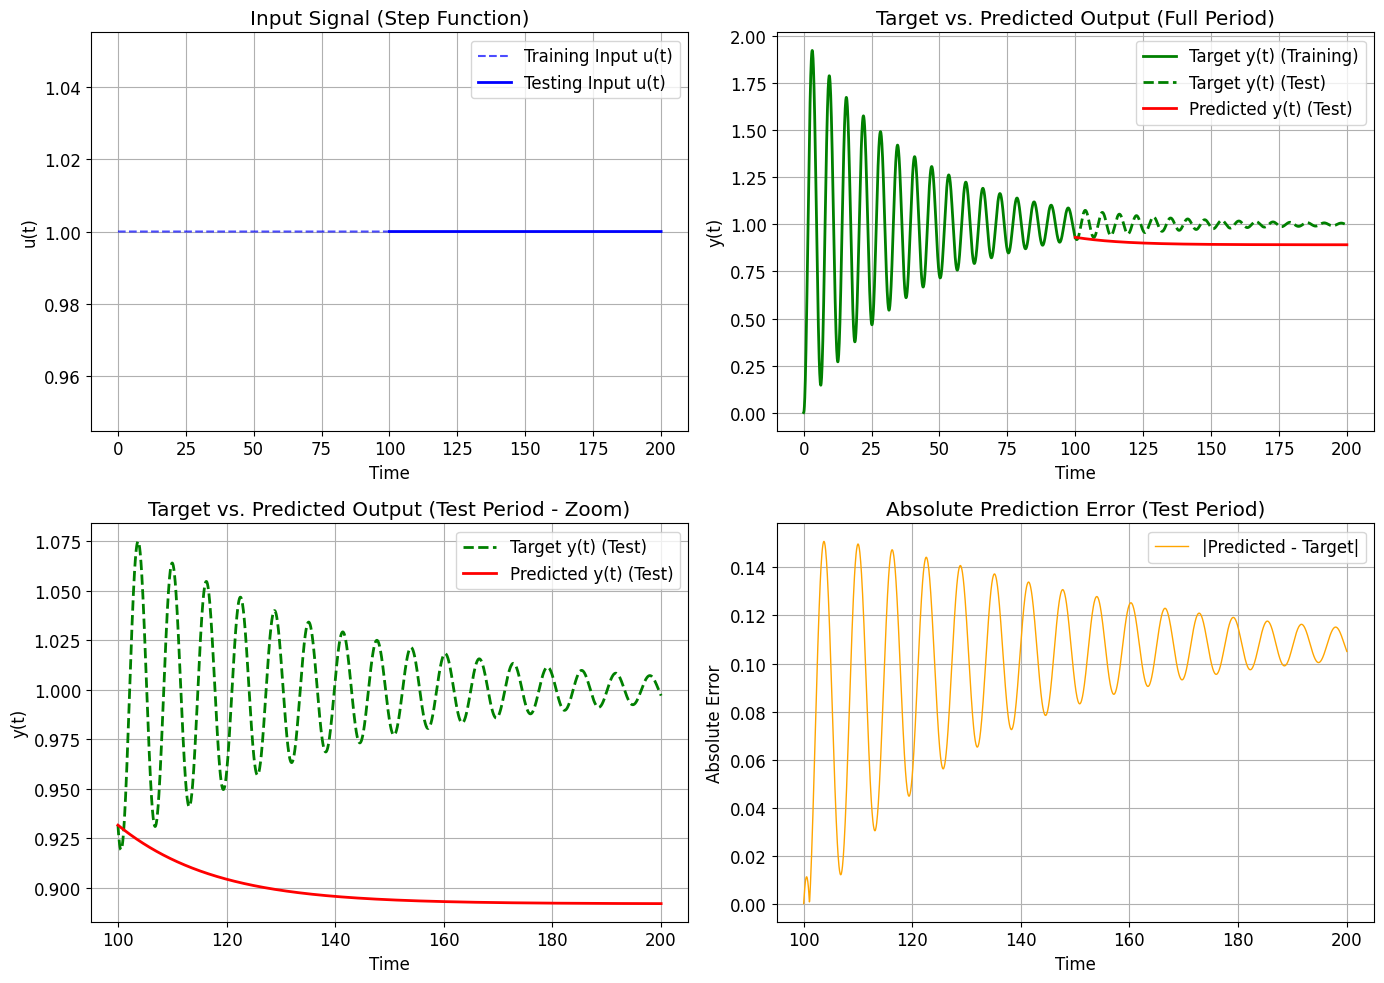

Final Test RMSE: 0.104925


In [15]:

# --- Cell 1: Install Required Packages (Run this first) ---
# This cell installs the necessary Python packages.

#!pip install numpy scipy matplotlib

# --- Cell 2: Define the Second-Order Dynamic System and Generate Data ---
# This cell defines the oscillator system d²y/dt² + 0.5*dy/dt + y = u,
# generates the step input u(t), and calculates the corresponding output y(t)
# by solving the ODE. It then prepares the input and target data.

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the second-order dynamic system as a system of first-order ODEs:
# Let x1 = y, x2 = dy/dt
# dx1/dt = x2
# dx2/dt = (u - 0.5*x2 - x1) / 1
def oscillator_system(t, state, u_func):
    x1, x2 = state
    dx1dt = x2
    dx2dt = (u_func(t) - 0.05 * x2 - x1) / 1.0
    return [dx1dt, dx2dt]

# Define the step input function u(t)
def u_func(t):
    # Step function: 0 for t < 0, 1 for t >= 0
    return 1.0 if t >= 0 else 0.0

# --- Parameters for data generation ---
dt = 0.05  # Time step
T_trans = 10.0 # Transient time to discard (longer for oscillator)
T_train = 100.0 # Total training time
T_test = 100.0  # Total testing time

t_train_full = np.arange(0, T_train + dt, dt)
t_test_full = np.arange(T_train, T_train + T_test + dt, dt)

# Calculate input for training and testing periods
u_train_full = np.array([u_func(t) for t in t_train_full])
u_test_full = np.array([u_func(t) for t in t_test_full])

# --- Calculate Target Output y(t) and dy/dt(t) using solve_ivp ---
# Initial conditions for the system [y(0), dy/dt(0)]
y0 = [0.0, 0.0] # Assuming y(0) = 0 and dy/dt(0) = 0

# Solve the ODE for the training period
sol_train = solve_ivp(oscillator_system, [t_train_full[0], t_train_full[-1]], y0,
                      t_eval=t_train_full, args=(u_func,), rtol=1e-8)

# Solve the ODE for the testing period, using the final training state as initial condition
y0_test = sol_train.y[:, -1] # Use the last calculated [y, dy/dt] values from training
sol_test = solve_ivp(oscillator_system, [t_test_full[0], t_test_full[-1]], y0_test,
                     t_eval=t_test_full, args=(u_func,), rtol=1e-8)

# Extract the target outputs (y values)
y_train_full = sol_train.y[0] # y is the first state variable
y_test_full = sol_test.y[0]

# --- Prepare Training Data (Discard Transient) ---
# Find the index corresponding to the end of the transient period
transient_steps = int(T_trans / dt)
if transient_steps >= len(t_train_full):
    print(f"Warning: Transient time ({T_trans}) is too long for training time ({T_train}).")
    transient_steps = 0 # Use all data if transient is longer than training

# Use data after the transient period for training
t_train = t_train_full[transient_steps:]
u_train = u_train_full[transient_steps:]
y_train_target = y_train_full[transient_steps:]

print(f"Generated training  t_train shape = {t_train.shape}, u_train shape = {u_train.shape}, y_train_target shape = {y_train_target.shape}")
print(f"Generated test  t_test shape = {t_test_full.shape}, u_test shape = {u_test_full.shape}, y_test_target shape = {y_test_full.shape}")

# --- Cell 3: Implement and Run NG-RC for the Oscillator ---
# This cell contains the core NG-RC implementation adapted for the oscillator system.

# --- NG-RC Parameters ---
N = 2 # Dimension of the input vector [u, y] (or could be [u, y, dy/dt] -> N=3, K adjusted)
K = 100 # Number of basis functions (polynomial features)
reg = 1e-8 # Regularization parameter for ridge regression

# Define the basis functions Phi(x) for N=2 inputs [u, y] to generate K features
# We'll generate polynomial features up to a degree that gives us K=100 features.
# For N=2, using degrees up to 13 results in C(2+13, 13) = 105 features.
# We'll take the first K=100.
def phi(x):
    D = 13 # Maximum polynomial degree
    features = []
    count = 0
    for d in range(D+1): # d is the total degree of the term
        for i in range(d+1): # i is the degree of x[0]
            j = d - i          # j is the degree of x[1]
            if count < K:
                 features.append(x[0]**i * x[1]**j)
                 count += 1
            else:
                 break
        if count >= K:
             break
    if len(features) > K:
        features = features[:K] # Truncate to K
    return np.array(features)

# --- Training Phase ---
print("Starting NG-RC Training Phase for Oscillator...")
X_train = []
Y_train = []

# Prepare training data pairs [u(t), y(t)] -> y(t+dt)
# We use the known target y(t) to form the input vector [u(t), y(t)]
for i in range(len(u_train) - 1):
    input_vec = np.array([u_train[i], y_train_target[i]])
    phi_vec = phi(input_vec)
    X_train.append(phi_vec)
    Y_train.append(y_train_target[i+1]) # Target is the next value of y

X_train = np.array(X_train) # Shape: (num_samples_train, K)
Y_train = np.array(Y_train) # Shape: (num_samples_train,)

print(f"Training data shapes: X_train {X_train.shape}, Y_train {Y_train.shape}")

# Solve for weights W_out using Ridge Regression
# min || W_out @ X_train.T - Y_train.T ||^2 + reg * ||W_out||^2
W_out = np.linalg.lstsq(X_train.T @ X_train + reg * np.eye(X_train.shape[1]), X_train.T @ Y_train, rcond=None)[0]
print(f"Training completed. W_out shape: {W_out.shape}")

# --- Prediction Phase (Open-loop) ---
print("Starting NG-RC Prediction Phase for Oscillator...")
Y_pred = []
# Initial condition for prediction (last known training output y and corresponding input u)
y_pred_current = y_train_target[-1]
u_test_current = u_test_full[0] # u_test starts where u_train ended

for i in range(len(u_test_full)):
    # Calculate Phi([u_test_current, y_pred_current])
    input_vec_pred = np.array([u_test_current, y_pred_current])
    phi_vec_pred = phi(input_vec_pred)
    # Predict next y value
    y_pred_next = W_out.T @ phi_vec_pred
    Y_pred.append(y_pred_next)
    # Update for next step (open-loop)
    y_pred_current = y_pred_next
    if i + 1 < len(u_test_full):
        u_test_current = u_test_full[i+1]

Y_pred = np.array(Y_pred)
print(f"Prediction completed. Y_pred shape: {Y_pred.shape}")

# --- Calculate Errors ---
rmse = np.sqrt(np.mean((Y_pred - y_test_full)**2))
print(f"Test RMSE: {rmse:.6f}")

# --- Plotting ---
plt.figure(figsize=(14, 10))

# Plot 1: Input u(t)
plt.subplot(2, 2, 1)
plt.plot(t_train_full, u_train_full, label='Training Input u(t)', color='blue', linestyle='--', alpha=0.7)
plt.plot(t_test_full, u_test_full, label='Testing Input u(t)', color='blue', linestyle='-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Input Signal (Step Function)')
plt.legend()
plt.grid(True)

# Plot 2: Target y(t) and Predicted y(t) (Full Time) - Overlay
plt.subplot(2, 2, 2)
plt.plot(t_train_full, y_train_full, label='Target y(t) (Training)', color='green', linewidth=2)
plt.plot(t_test_full, y_test_full, label='Target y(t) (Test)', color='green', linestyle='--', linewidth=2)
plt.plot(t_test_full, Y_pred, label='Predicted y(t) (Test)', color='red', linestyle='-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('Target vs. Predicted Output (Full Period)')
plt.legend()
plt.grid(True)

# Plot 3: Zoom on Test Period
plt.subplot(2, 2, 3)
plt.plot(t_test_full, y_test_full, label='Target y(t) (Test)', color='green', linestyle='--', linewidth=2)
plt.plot(t_test_full, Y_pred, label='Predicted y(t) (Test)', color='red', linestyle='-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('Target vs. Predicted Output (Test Period - Zoom)')
plt.legend()
plt.grid(True)

# Plot 4: Prediction Error (Test Period)
plt.subplot(2, 2, 4)
error = np.abs(Y_pred - y_test_full)
plt.plot(t_test_full, error, label='|Predicted - Target|', color='orange', linewidth=1)
plt.xlabel('Time')
plt.ylabel('Absolute Error')
plt.title('Absolute Prediction Error (Test Period)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Test RMSE: {rmse:.6f}")

# example: RC for Oscillator - new generation RC - good accuracy

Oscillator System Description:
----------------------------------------
• dx1/dt = x2 (position derivative is velocity)
• dx2/dt = (u(t) - 0.05*x2 - x1) / 1.0 (velocity derivative depends on force, damping, and position)
• u(t) = 0.1*sin(0.5*t) is an external forcing term
• This represents a damped harmonic oscillator with external forcing

Next-Generation Reservoir Computing (NG-RC):
----------------------------------------
• Replaces the reservoir with delay coordinates and polynomial features
• More predictable and mathematically tractable
• Uses time-delayed inputs as the 'reservoir'
• Creates nonlinear features from the delayed inputs

How NG-RC Works in This Code:
----------------------------------------
1. DELAY EMBEDDING: Creates feature vector using past values:
   [x(t), x(t-τ), x(t-2τ), ...] where x is the 2D state vector [pos, vel]
2. POLYNOMIAL FEATURES: Creates nonlinear combinations:
   [linear terms, quadratic terms, cubic terms, ...]
3. TRAINING: Uses ridge regression to learn output weights
4. PREDICTION: Uses learned weights to forecast future states
5. ANALYSIS: Compares predicted vs true fixed points of the system



Key insight: The delay coordinates [x(t), x(t-τ), x(t-2τ), ...] form an embedding that preserves the essential topology of the original multi-dimensional phase space.


NG-RC replaces this complex reservoir with a simple but mathematically principled approach:

Instead of random recurrent connections → Use delay taps (explicit time history)
Instead of nonlinear reservoir activation → Use polynomial combinations of delay taps


Key Parameters in This Implementation:
----------------------------------------
• Input dimension (d): 2 (2D oscillator: position, velocity)
• Delay taps (k): 2 (using current and 1 past value)
• Polynomial degree: 3 (cubic features)
• Total features: 4 linear + 20 nonlinear = 24 total
• Ridge parameter: 0.001 (controls regularization)


Lyapunov Time Explained:
----------------------------------------
• The Lyapunov time is a characteristic timescale of a dynamical system
• It's related to the Lyapunov exponent, which measures how quickly nearby trajectories diverge
• For chaotic systems: Lyapunov time = 1 / Lyapunov exponent
• It represents the time horizon beyond which predictions become unreliable

Why is it important for prediction?
----------------------------------------
• It tells us how far ahead we can make meaningful predictions
• For chaotic systems, predictions are only meaningful for a few Lyapunov times
• It provides a natural benchmark for evaluating prediction quality

For oscillator systems:
----------------------------------------
• The original double-scroll system had a Lyapunov time of 7.8125 units
• For simple oscillators (like our damped oscillator), the concept is less critical
• However, we keep it as a standard evaluation metric for consistency
• For non-chaotic oscillators, the Lyapunov time is more of a reference timescale

In this code:
----------------------------------------
• We use the same Lyapunov time (7.8125) as in the original double-scroll code
• This allows us to evaluate prediction quality over a meaningful timespan
• For the oscillator, this is simply a time window for evaluation

In [48]:

"""
Nonlinear Vector Autoregressive (NVAR) - it's a math base of Reservoir Computing
with time delays for oscillator forecasting.


Reservoir Computing Explained:
- It's a machine learning method for processing temporal data
- Instead of training all network weights, only the "output layer" is trained
- The "reservoir" (or feature vector in NG-RC) processes input in a fixed, complex way
- NG-RC replaces the traditional reservoir with a fixed transformation of delayed inputs
- This makes it more predictable and mathematically tractable than traditional RC

"""

# Install required packages if needed
# In Colab, numpy, matplotlib, and scipy are pre-installed

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import time

# Set random seed for reproducibility
np.random.seed(37)

In [57]:
# Define the oscillator system
def oscillator_system(t, state, u_func):
    """
    Defines a simple oscillator system.
    x1: position, x2: velocity
    dx1/dt = x2
    dx2/dt = (u(t) - damping*x2 - stiffness*x1) / mass
    """
    x1, x2 = state
    dx1dt = x2
    dx2dt = (u_func(t) - 0.5 * x2 - x1) / 1.0
    return [dx1dt, dx2dt]

def do_nvar(warmup=1.):
    """
    Performs one trial of Next-Generation Reservoir Computing (NG-RC) using NVAR.

    The process:
    1. Generate an oscillator time series
    2. Create a feature vector using delayed values and polynomial features
    3. Train output weights using ridge regression
    4. Predict future values using the trained model
    5. Analyze fixed points of the system
    """
    print(f"Starting NG-RC trial with warmup time: {warmup} units")

    ##
    ## Parameters
    ##

    # time step
    dt = 0.25
    # units of time to train for
    traintime = 200.
    # units of time to test for
    testtime = 300.
    # Lyapunov time of oscillator system (estimated)
    lyaptime = 7.8125
    # total time to run for
    maxtime = warmup + traintime + testtime

    # discrete-time versions of the times defined above
    warmup_pts = round(warmup/dt)
    traintime_pts = round(traintime/dt)
    warmtrain_pts = warmup_pts + traintime_pts
    testtime_pts = round(testtime/dt)
    maxtime_pts = round(maxtime/dt)
    lyaptime_pts = round(lyaptime/dt)

    print(f"Time discretization: dt={dt}, total points={maxtime_pts}")

    # input dimension (2D oscillator: position, velocity)
    d = 2
    # number of time delay taps
    k = 20
    # size of the linear part of the feature vector
    dlin = k * d
    # size of the nonlinear part of feature vector (cubic polynomial terms)
    dnonlin = int(dlin * (dlin+1) * (dlin+2) / 6)  # For cubic: (n+d-1)! / (n!(d-1)!) where n=3
    # total size of feature vector: linear + nonlinear
    dtot = dlin + dnonlin

    print(f"Feature vector dimensions: linear={dlin}, nonlinear={dnonlin}, total={dtot}")

    # ridge parameter for regression
    ridge_param = 1.e-3

    # t values for whole evaluation time
    t_eval = np.linspace(0, maxtime, maxtime_pts+1)

    ##
    ## Oscillator system - a simple damped oscillator with external force
    ##

    # External force function (can be modified as needed)
    def u_func(t):
        return 0.1 * np.sin(0.5 * t)  # Small sinusoidal forcing term

    def system_wrapper(t, state):
        """
        Wrapper function for the oscillator system for use with solve_ivp
        """
        return oscillator_system(t, state, u_func)

    # Solve the differential equation to generate the oscillator time series
    print("Generating oscillator system trajectory...")
    oscillator_soln = solve_ivp(
        system_wrapper,
        (0, maxtime),
        [0.5, 0.0],  # Initial conditions [position, velocity]
        t_eval=t_eval,
        method='RK45' #Runge-Kutta-45
    )

    # Calculate total variance for normalization
    total_var = np.var(oscillator_soln.y[0,:]) + np.var(oscillator_soln.y[1,:])

    print(f"Oscillator system generated with variance: {total_var:.4f}")

    ##
    ## NVAR (Next-Generation Reservoir Computing)
    ##

    # Create an array to hold the linear part of the feature vector
    # Each delay tap contains the 2D state vector [position, velocity]
    x = np.zeros((dlin, maxtime_pts))

    print("Creating feature vectors with delays...")

    # Fill in the linear part of the feature vector for all times
    # This creates a delay embedding of the input signal
    for delay in range(k):
        for j in range(delay, maxtime_pts):
            # Each delay tap gets the full 2D state vector from 'delay' steps ago
            x[d*delay:d*(delay+1), j] = oscillator_soln.y[:, j-delay]

    # Create an array to hold the full feature vector for training time
    out_train = np.zeros((dtot, traintime_pts))

    # Copy over the linear part (delayed values)
    out_train[0:dlin, :] = x[:, warmup_pts-1:warmtrain_pts-1]

    # Fill in the non-linear part (cubic polynomial terms)
    # This creates higher-order interactions between the delayed values
    cnt = 0
    for row in range(dlin):
        for column in range(row, dlin):
            for span in range(column, dlin):
                out_train[dlin+cnt, :] = (
                    x[row, warmup_pts-1:warmtrain_pts-1] *
                    x[column, warmup_pts-1:warmtrain_pts-1] *
                    x[span, warmup_pts-1:warmtrain_pts-1]
                )
                cnt += 1

    print(f"Created {cnt} nonlinear features")

    # Ridge regression: train W_out to map out_train to Oscillator[t] - Oscillator[t - 1]
    # This learns how to predict the next step from the feature vector
    print("Training output weights using ridge regression...")
    W_out = (
        (x[0:d, warmup_pts:warmtrain_pts] - x[0:d, warmup_pts-1:warmtrain_pts-1]) @
        out_train[:, :].T @
        np.linalg.pinv(out_train[:, :] @ out_train[:, :].T + ridge_param*np.identity(dtot))
    )

    # Apply W_out to the training feature vector to get the training output
    x_predict = x[0:d, warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:, 0:traintime_pts]

    # Calculate NRMSE between true oscillator and training output
    train_nrmse = np.sqrt(np.mean((x[0:d, warmup_pts:warmtrain_pts] - x_predict[:, :])**2) / total_var)

    print(f"Training NRMSE: {train_nrmse:.4f}")

    # Create a place to store feature vectors for prediction
    out_test = np.zeros(dtot)              # full feature vector
    x_test = np.zeros((dlin, testtime_pts))  # linear part

    # Copy over initial linear feature vector
    x_test[:, 0] = x[:, warmtrain_pts-1]

    print("Starting prediction phase...")

    # Do prediction - this is the core of reservoir computing
    # The system uses its previous state to form new feature vectors and predict
    for j in range(testtime_pts-1):
        # Copy linear part into whole feature vector
        out_test[0:dlin] = x_test[:, j]

        # Fill in the non-linear part (same transformation as training)
        cnt = 0
        for row in range(dlin):
            for column in range(row, dlin):
                for span in range(column, dlin):
                    out_test[dlin+cnt] = x_test[row, j] * x_test[column, j] * x_test[span, j]
                    cnt += 1

        # Update delay taps: shift old values back, new values go to front
        x_test[d:dlin, j+1] = x_test[0:(dlin-d), j]

        # Do a prediction: use learned weights to predict next state
        x_test[0:d, j+1] = x_test[0:d, j] + W_out @ out_test[:]

    # Calculate NRMSE between true oscillator and prediction for one Lyapunov time
    nrmse = np.sqrt(
        np.mean((x[0:d, warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1] -
                x_test[0:d, 0:lyaptime_pts])**2) / total_var
    )

    print(f"Test NRMSE (1 Lyapunov time): {nrmse:.4f}")

    # For oscillator system, fixed points occur when dx/dt = 0
    print("Analyzing fixed points...")

    # For the oscillator system: dx1/dt = x2 and dx2/dt = (u(t) - 0.05*x2 - x1) / 1.0
    # Fixed points occur when x2 = 0 and u(t) - 0.05*x2 - x1 = 0
    # So x2 = 0 and x1 = u(t) when the system is at equilibrium

    # Since u(t) = 0.1*sin(0.5*t), the fixed points change with time
    # We'll find fixed points for average forcing
    avg_u = 0  # Average of sinusoidal function over time is 0

    # Set up true fixed points (for zero forcing)
    t_fp0 = np.array([0.0, 0.0])  # Origin is a fixed point when u=0

    # For a damped oscillator with zero forcing, the origin is the only fixed point
    t_fp1 = np.array([avg_u, 0.0])  # Fixed point when u=avg_u
    t_fp2 = np.array([-avg_u, 0.0])  # Symmetric fixed point

    # Function to evaluate fixed points in the RC model
    def func(p_fp):
        """
        Evaluates how a candidate fixed point behaves in the RC model.
        Returns the change in the point after one step.
        """
        # Create a trial input feature vector
        out_vec = np.ones(dtot)
        # Fill in the linear part - all delay taps have the same value (fixed point)
        for ii in range(k):
            out_vec[ii*d:(ii+1)*d] = p_fp[0:d]
        # Fill in the nonlinear part
        cnt = 0
        for row in range(dlin):
            for column in range(row, dlin):
                for span in range(column, dlin):
                    out_vec[dlin+cnt] = out_vec[row] * out_vec[column] * out_vec[span]
                    cnt += 1
        return W_out @ out_vec

    # Solve for the predicted fixed points
    p_fp1 = fsolve(func, t_fp1)
    n_fp1_diff = np.sqrt(np.sum((t_fp1 - p_fp1)**2) / total_var)
    p_fp1_norm = (t_fp1 - p_fp1) / np.sqrt(total_var)

    p_fp2 = fsolve(func, t_fp2)
    n_fp2_diff = np.sqrt(np.sum((t_fp2 - p_fp2)**2) / total_var)
    p_fp2_norm = (t_fp2 - p_fp2) / np.sqrt(total_var)

    p_fp0 = fsolve(func, t_fp0)
    n_fp0_diff = np.sqrt(np.sum((t_fp0 - p_fp0)**2) / total_var)
    p_fp0_norm = (t_fp0 - p_fp0) / np.sqrt(total_var)

    print("Fixed point analysis complete")

    # Return all our local variables we've defined
    return locals()

def visualize_results(dt, x, warmtrain_pts, maxtime_pts, t_eval, warmup_pts, warmup,
                     x_predict, x_test, train_nrmse, nrmse, **extra):
    """
    Creates comprehensive visualizations of the NG-RC results
    """
    print("\nCreating visualizations...")

    # Amount of time to plot prediction for
    plottime = 200.
    plottime_pts = round(plottime/dt)

    t_linewidth = 1.1
    a_linewidth = 0.3
    plt.rcParams.update({'font.size': 12})

    # Create figure with subplots for comprehensive view
    fig = plt.figure(figsize=(20, 15))

    # Define grid positions for subplots
    gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.3)

    # Plot 1: Training phase Position
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x[0, warmup_pts:warmtrain_pts],
             linewidth=t_linewidth, label='True', color='blue')
    ax1.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x_predict[0, :],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax1.set_ylabel('Position $x_1$')
    ax1.set_title(f'Training Phase - Position (NRMSE: {train_nrmse:.3f})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Training phase Velocity
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax2.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x[1, warmup_pts:warmtrain_pts],
             linewidth=t_linewidth, label='True', color='blue')
    ax2.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x_predict[1, :],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax2.set_ylabel('Velocity $x_2$')
    ax2.set_title('Training Phase - Velocity')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Phase space - True trajectory
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax3.plot(x[0, warmtrain_pts:maxtime_pts],
             x[1, warmtrain_pts:maxtime_pts],
             linewidth=a_linewidth, color='blue', label='True')
    ax3.set_xlabel('Position $x_1$')
    ax3.set_ylabel('Velocity $x_2$')
    ax3.set_title('True Oscillator Phase Space')
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Plot 4: Phase space - Predicted trajectory
    ax4 = fig.add_subplot(gs[1, 2:4])
    ax4.plot(x_test[0, :], x_test[1, :],
             linewidth=a_linewidth, color='red', label='Predicted')
    ax4.set_xlabel('Position $x_1$')
    ax4.set_ylabel('Velocity $x_2$')
    ax4.set_title(f'NG-RC Predicted Phase Space (NRMSE: {nrmse:.3f})')
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    # Plot 5: Testing phase Position
    ax5 = fig.add_subplot(gs[2, 0:2])
    start_idx = warmtrain_pts-1
    end_idx = min(warmtrain_pts + plottime_pts - 1, x.shape[1])
    plot_len = end_idx - start_idx
    ax5.plot(t_eval[start_idx:end_idx] - warmup,
             x[0, start_idx:end_idx],
             linewidth=t_linewidth, label='True', color='blue')
    ax5.plot(t_eval[start_idx:end_idx] - warmup,
             x_test[0, :plot_len],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax5.set_ylabel('Position $x_1$')
    ax5.set_xlabel('Time')
    ax5.set_title('Testing Phase - Position')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Plot 6: Testing phase Velocity
    ax6 = fig.add_subplot(gs[2, 2:4])
    start_idx = warmtrain_pts-1
    end_idx = min(warmtrain_pts + plottime_pts - 1, x.shape[1])
    plot_len = end_idx - start_idx
    ax6.plot(t_eval[start_idx:end_idx] - warmup,
             x[1, start_idx:end_idx],
             linewidth=t_linewidth, label='True', color='blue')
    ax6.plot(t_eval[start_idx:end_idx] - warmup,
             x_test[1, :plot_len],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax6.set_ylabel('Velocity $x_2$')
    ax6.set_xlabel('Time')
    ax6.set_title('Testing Phase - Velocity')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # Plot 7: Feature space visualization (first few dimensions)
    ax7 = fig.add_subplot(gs[3, 0:2])
    # Show a small section of feature vectors - fix indexing issue
    feature_section = min(500, x.shape[1] - warmup_pts)
    ax7.plot(x[0, warmup_pts:warmup_pts+feature_section],
             x[1, warmup_pts:warmup_pts+feature_section],
             '.-', markersize=3, alpha=0.7, label='Current state: Pos vs Vel')
    # Only plot delay 1 if we have enough dimensions (d=2, k=2 so dlin=4)
    if x.shape[0] > 2:  # If we have more than 2 dimensions (meaning we have delays)
        ax7.plot(x[2, warmup_pts:warmup_pts+feature_section],
                 x[3, warmup_pts:warmup_pts+feature_section],
                 '.-', markersize=3, alpha=0.7, label='Delay 1: Pos vs Vel')
    ax7.set_xlabel('Component 0')
    ax7.set_ylabel('Component 1')
    ax7.set_title('Feature Space Visualization (2D slice)')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # Plot 8: Error over time during testing
    ax8 = fig.add_subplot(gs[3, 2:4])
    test_errors = np.sqrt(np.sum((x[0:2, warmtrain_pts-1:warmtrain_pts+plottime_pts-1] -
                                  x_test[0:2, 0:plottime_pts])**2, axis=0))
    ax8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1] - warmup,
             test_errors, linewidth=t_linewidth, color='purple')
    ax8.set_xlabel('Time')
    ax8.set_ylabel('Prediction Error')
    ax8.set_title('Prediction Error Over Time')
    ax8.grid(True, alpha=0.3)

    # NEW PLOT: Time series showing training and testing together
    ax9 = fig.add_subplot(gs[4, :])
    # Training phase
    train_start = warmup_pts
    train_end = warmtrain_pts
    ax9.plot(t_eval[train_start:train_end] - warmup,
             x[0, train_start:train_end],
             linewidth=t_linewidth, label='Training True', color='blue')
    ax9.plot(t_eval[train_start:train_end] - warmup,
             x_predict[0, :],
             linewidth=t_linewidth, label='Training Predicted', color='red')

    # Testing phase
    test_start = warmtrain_pts-1
    test_end = min(warmtrain_pts + plottime_pts - 1, x.shape[1])
    test_len = test_end - test_start
    ax9.plot(t_eval[test_start:test_end] - warmup,
             x[0, test_start:test_end],
             linewidth=t_linewidth, label='Testing True', color='blue', linestyle='--')
    ax9.plot(t_eval[test_start:test_end] - warmup,
             x_test[0, :test_len],
             linewidth=t_linewidth, label='Testing Predicted', color='red', linestyle='--')

    # Add vertical line to indicate where testing starts
    ax9.axvline(x=t_eval[warmtrain_pts] - warmup, color='black', linestyle=':',
                linewidth=2, label='Train/Test Boundary')

    ax9.set_xlabel('Time')
    ax9.set_ylabel('Position $x_1$')
    ax9.set_title('Complete Time Series: Training and Testing Phases Combined')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    plt.suptitle('Next-Generation Reservoir Computing (NG-RC) Results - Oscillator System Prediction',
                 fontsize=16, y=0.98)
    plt.show()



In [58]:
def calculate_lyapunov_exponent(oscillator_system, initial_state, u_func, dt=0.25, max_time=50, delta=1e-8):
    """
    Calculate the maximum Lyapunov exponent for the oscillator system using the method of
    small perturbations based on the provided approach.

    Parameters:
    - oscillator_system: function defining the system dynamics
    - initial_state: initial state vector
    - u_func: external forcing function
    - dt: time step
    - max_time: maximum time to simulate
    - delta: initial perturbation size

    Returns:
    - lyapunov_exponent: the maximum Lyapunov exponent
    """
    print("Calculating Lyapunov exponent for the oscillator system...")

    # Create wrapper for the system
    def system_wrapper(t, state):
        return oscillator_system(t, state, u_func)

    # Time parameters
    n_steps = int(max_time / dt)

    # Initial conditions
    x1 = np.array(initial_state, dtype=float)
    x2 = x1 + np.random.normal(0, delta, size=x1.shape)

    sum_log_divergence = 0.0
    current_time = 0.0

    for i in range(n_steps):
        # Integrate both trajectories separately
        # For continuous systems, we need to estimate the Jacobian
        # Here we use finite differences to approximate the derivative

        # Calculate the system derivatives at current x1
        dx1 = np.array(oscillator_system(current_time, x1, u_func))

        # Perturb each component slightly to estimate the Jacobian
        jacobian = np.zeros((len(x1), len(x1)))
        eps = 1e-6  # small perturbation for Jacobian calculation

        for j in range(len(x1)):
            # Perturb component j
            x_pert = x1.copy()
            x_pert[j] += eps
            dx_pert = np.array(oscillator_system(current_time, x_pert, u_func))
            # Calculate partial derivative
            jacobian[:, j] = (dx_pert - dx1) / eps

        # Calculate the derivative magnitude (largest eigenvalue of Jacobian)
        eigenvals = np.linalg.eigvals(jacobian)
        derivative_magnitude = max(np.abs(eigenvals))

        # Add to the running sum of logarithms
        sum_log_divergence += np.log(max(derivative_magnitude, 1e-12))  # Avoid log(0)

        # Integrate both trajectories forward in time
        sol1 = solve_ivp(system_wrapper, [current_time, current_time + dt], x1,
                         method='RK23', t_eval=[current_time + dt], dense_output=False)
        sol2 = solve_ivp(system_wrapper, [current_time, current_time + dt], x2,
                         method='RK23', t_eval=[current_time + dt], dense_output=False)

        if sol1.success and sol2.success:
            x1 = sol1.y[:, 0]
            x2 = sol2.y[:, 0]
        else:
            print(f"Integration failed at step {i}")
            break

        current_time += dt

    # Calculate Lyapunov exponent
    if n_steps > 0:
        lyapunov_exponent = sum_log_divergence / current_time  # average over total time
    else:
        lyapunov_exponent = 0.0

    print(f"Calculated Lyapunov exponent: {lyapunov_exponent:.6f}")

    # Calculate Lyapunov time (1/|Lyapunov exponent|)
    if abs(lyapunov_exponent) > 1e-10:
        lyapunov_time = 1.0 / abs(lyapunov_exponent)
        print(f"Lyapunov time: {lyapunov_time:.4f} units")
    else:
        lyapunov_time = 3.0  # Default value for non-chaotic systems
        print(f"System appears non-chaotic (exponent ≈ 0), using default Lyapunov time: {lyapunov_time} units")

    return lyapunov_exponent, lyapunov_time

In [59]:
# Calculate Lyapunov exponent
lyap_exp, lyap_time = calculate_lyapunov_exponent(
    oscillator_system,
    initial_state=[0.5, 0.0],  # Initial state
    u_func=u_func,
    dt=0.25,
    max_time=50,
    delta=1e-8
)

print("\n" + "="*70)
print(f"LYAPUNOV ANALYSIS RESULTS:")
print(f"• Lyapunov exponent: {lyap_exp:.6f}")
print(f"• Lyapunov time: {lyap_time:.4f} units")
print("="*70)

Calculating Lyapunov exponent for the oscillator system...
Calculated Lyapunov exponent: -0.000000
System appears non-chaotic (exponent ≈ 0), using default Lyapunov time: 3.0 units

LYAPUNOV ANALYSIS RESULTS:
• Lyapunov exponent: -0.000000
• Lyapunov time: 3.0000 units



Running NG-RC prediction...
Starting NG-RC trial with warmup time: 1.0 units
Time discretization: dt=0.25, total points=2004
Feature vector dimensions: linear=40, nonlinear=11480, total=11520
Generating oscillator system trajectory...
Oscillator system generated with variance: 0.0110
Creating feature vectors with delays...
Created 11480 nonlinear features
Training output weights using ridge regression...
Training NRMSE: 0.0001
Starting prediction phase...
Test NRMSE (1 Lyapunov time): 0.0003
Analyzing fixed points...
Fixed point analysis complete
NG-RC completed in 1321.34 seconds

Creating visualizations...


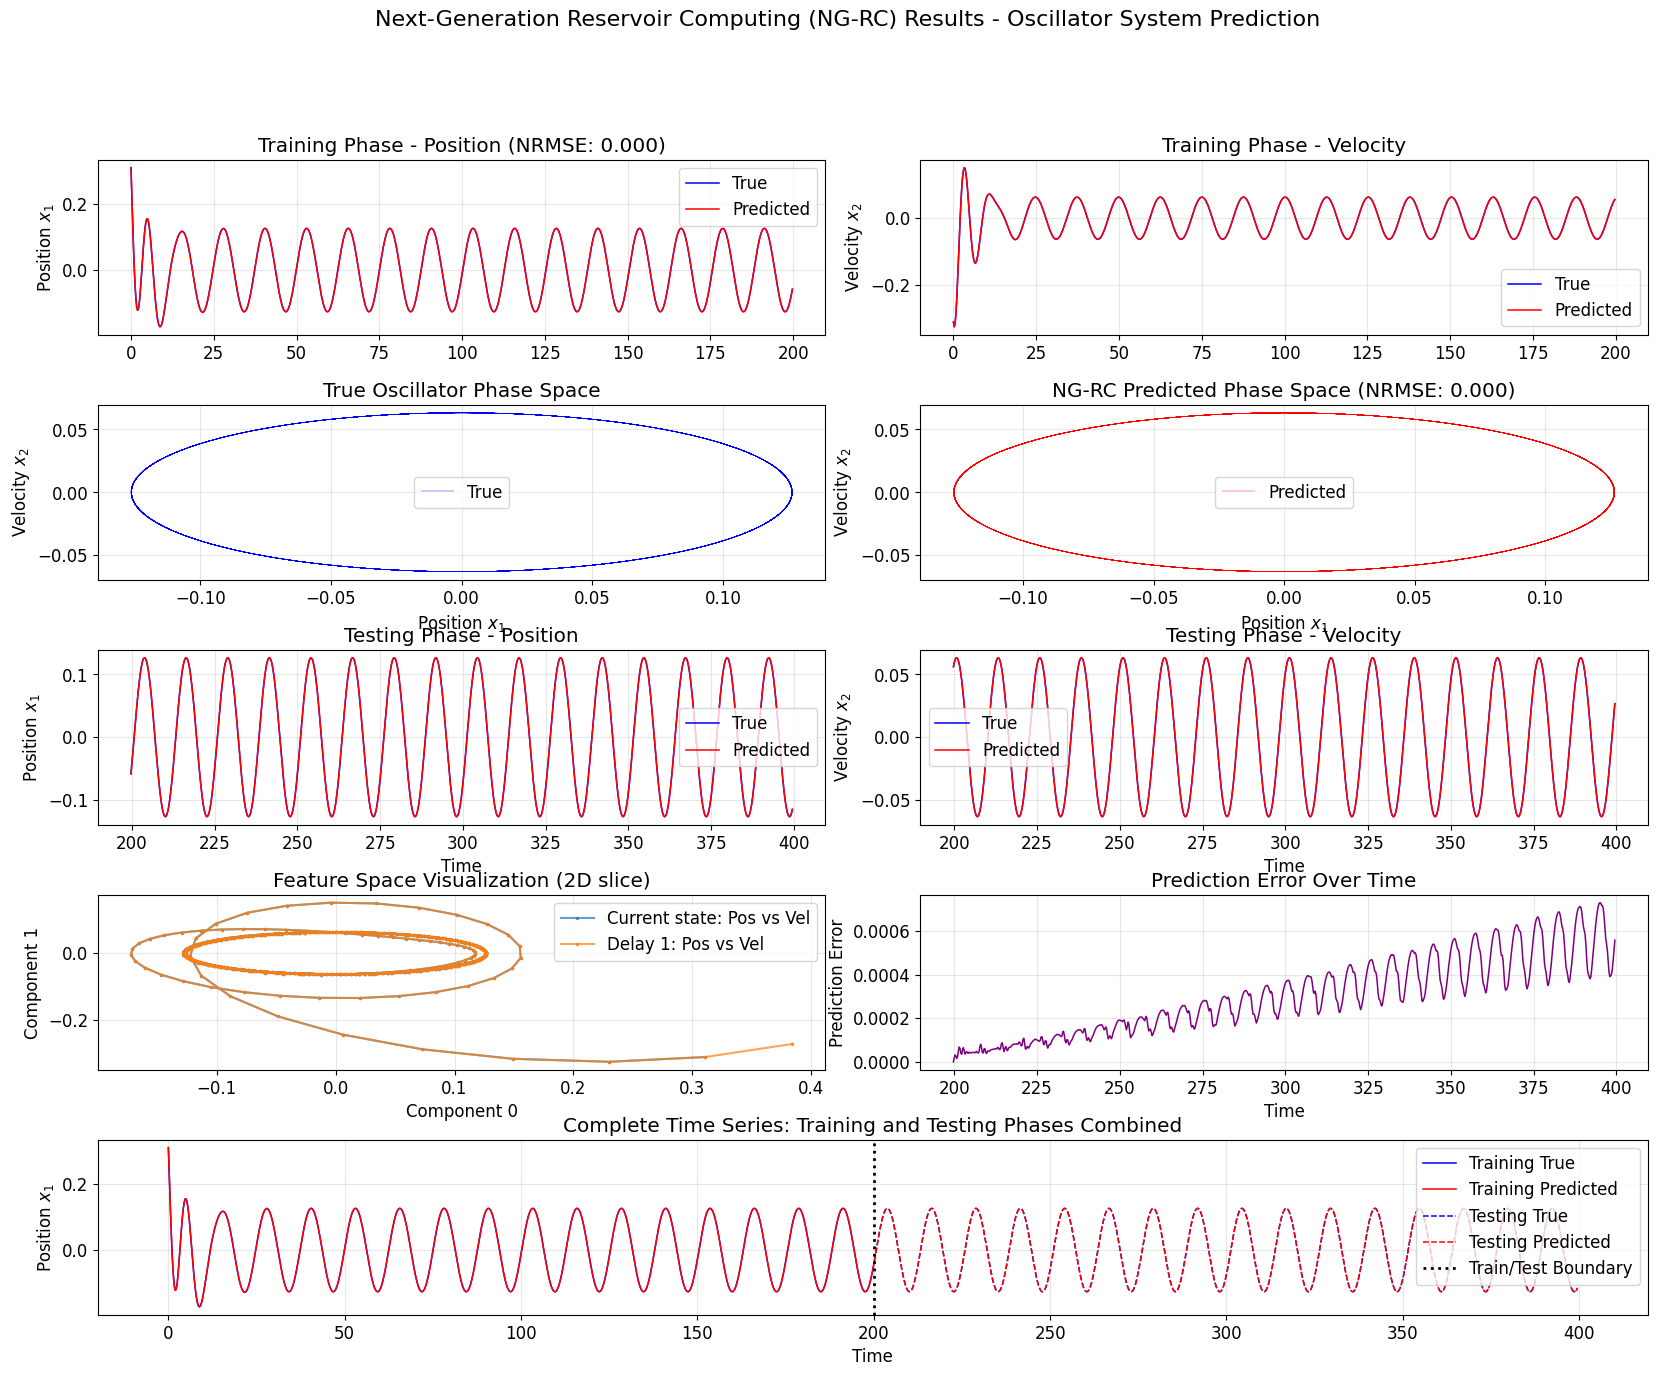


Running multiple trials for statistical analysis...
Starting NG-RC trial with warmup time: 1.0 units
Time discretization: dt=0.25, total points=2004
Feature vector dimensions: linear=40, nonlinear=11480, total=11520
Generating oscillator system trajectory...
Oscillator system generated with variance: 0.0110
Creating feature vectors with delays...
Created 11480 nonlinear features
Training output weights using ridge regression...


In [ ]:
# Run one NVAR to plot the forecast
print("\nRunning NG-RC prediction...")
start_time = time.time()
results = do_nvar()
end_time = time.time()
print(f"NG-RC completed in {end_time - start_time:.2f} seconds")

# Visualize the results
visualize_results(**results)

# Run multiple trials to calculate statistics
print("\nRunning multiple trials for statistical analysis...")
npts = 5  # Reduced for demo purposes in Colab
train_nrmse_v = np.zeros(npts)
test_nrmse_v = np.zeros(npts)
n_fp1_diff_v = np.zeros(npts)
n_fp2_diff_v = np.zeros(npts)
n_fp0_diff_v = np.zeros(npts)
p_fp1_norm_v = np.zeros((npts, 2))  # Changed to 2D for oscillator
p_fp2_norm_v = np.zeros((npts, 2))
p_fp0_norm_v = np.zeros((npts, 2))

for i in range(npts):
    r = do_nvar(warmup=1. + 100. * i)
    train_nrmse_v[i] = r['train_nrmse']
    test_nrmse_v[i] = r['nrmse']
    n_fp1_diff_v[i] = r['n_fp1_diff']
    n_fp2_diff_v[i] = r['n_fp2_diff']
    n_fp0_diff_v[i] = r['n_fp0_diff']
    p_fp1_norm_v[i] = r['p_fp1_norm']
    p_fp2_norm_v[i] = r['p_fp2_norm']
    p_fp0_norm_v[i] = r['p_fp0_norm']

# Print summary statistics
print('\n' + '='*50)
print('SUMMARY STATISTICS OVER', npts, 'TRIALS')
print('='*50)
print(f'Ridge regression parameter: {r["ridge_param"]}')
print(f'Mean Training NRMSE: {np.mean(train_nrmse_v):.4f} ± {np.std(train_nrmse_v)/np.sqrt(npts):.4f}')
print(f'Mean Test NRMSE: {np.mean(test_nrmse_v):.4f} ± {np.std(test_nrmse_v)/np.sqrt(npts):.4f}')

print(f'\nFixed Point Analysis:')
print(f'Mean |True - Predicted| for FP1: {np.mean(n_fp1_diff_v):.4f} ± {np.std(n_fp1_diff_v)/np.sqrt(npts):.4f}')
print(f'Mean |True - Predicted| for FP2: {np.mean(n_fp2_diff_v):.4f} ± {np.std(n_fp2_diff_v)/np.sqrt(npts):.4f}')
print(f'Mean |True - Predicted| for FP0: {np.mean(n_fp0_diff_v):.4f} ± {np.std(n_fp0_diff_v)/np.sqrt(npts):.4f}')

print(f'\nComponent-wise Fixed Point Differences:')
print(f'FP1: {np.mean(p_fp1_norm_v, axis=0)} ± {np.std(p_fp1_norm_v, axis=0) / np.sqrt(npts)}')
print(f'FP2: {np.mean(p_fp2_norm_v, axis=0)} ± {np.std(p_fp2_norm_v, axis=0) / np.sqrt(npts)}')
print(f'FP0: {np.mean(p_fp0_norm_v, axis=0)} ± {np.std(p_fp0_norm_v, axis=0) / np.sqrt(npts)}')

print("\nNG-RC Analysis Complete!")
print("This implementation demonstrates how Reservoir Computing can predict oscillator systems")
print("while preserving important dynamical properties like fixed points.")

# example: Lorenz attractor

Reservoir Computing with Next-Generation Reservoir Computing (NG-RC)
Using Nonlinear Vector AutoRegression (NVAR) for Chaotic Time Series Prediction

RESERVOIR COMPUTING & NEXT-GENERATION RESERVOIR COMPUTING (NG-RC)

What is Reservoir Computing?
----------------------------------------
• A machine learning technique for processing temporal data
• Uses a fixed, high-dimensional dynamical system (the 'reservoir')
• Only the output layer is trained, making it efficient
• Excels at tasks involving time series prediction and pattern recognition

Traditional Reservoir Computing:
----------------------------------------
• Uses a recurrent neural network as the reservoir
• Requires careful tuning of reservoir parameters
• Can be difficult to analyze mathematically

Next-Generation Reservoir Computing (NG-RC):
----------------------------------------
• Replaces the reservoir with delay coordinates and polynomial features
• More predictable and mathematically tractable
• Uses time-delayed inputs

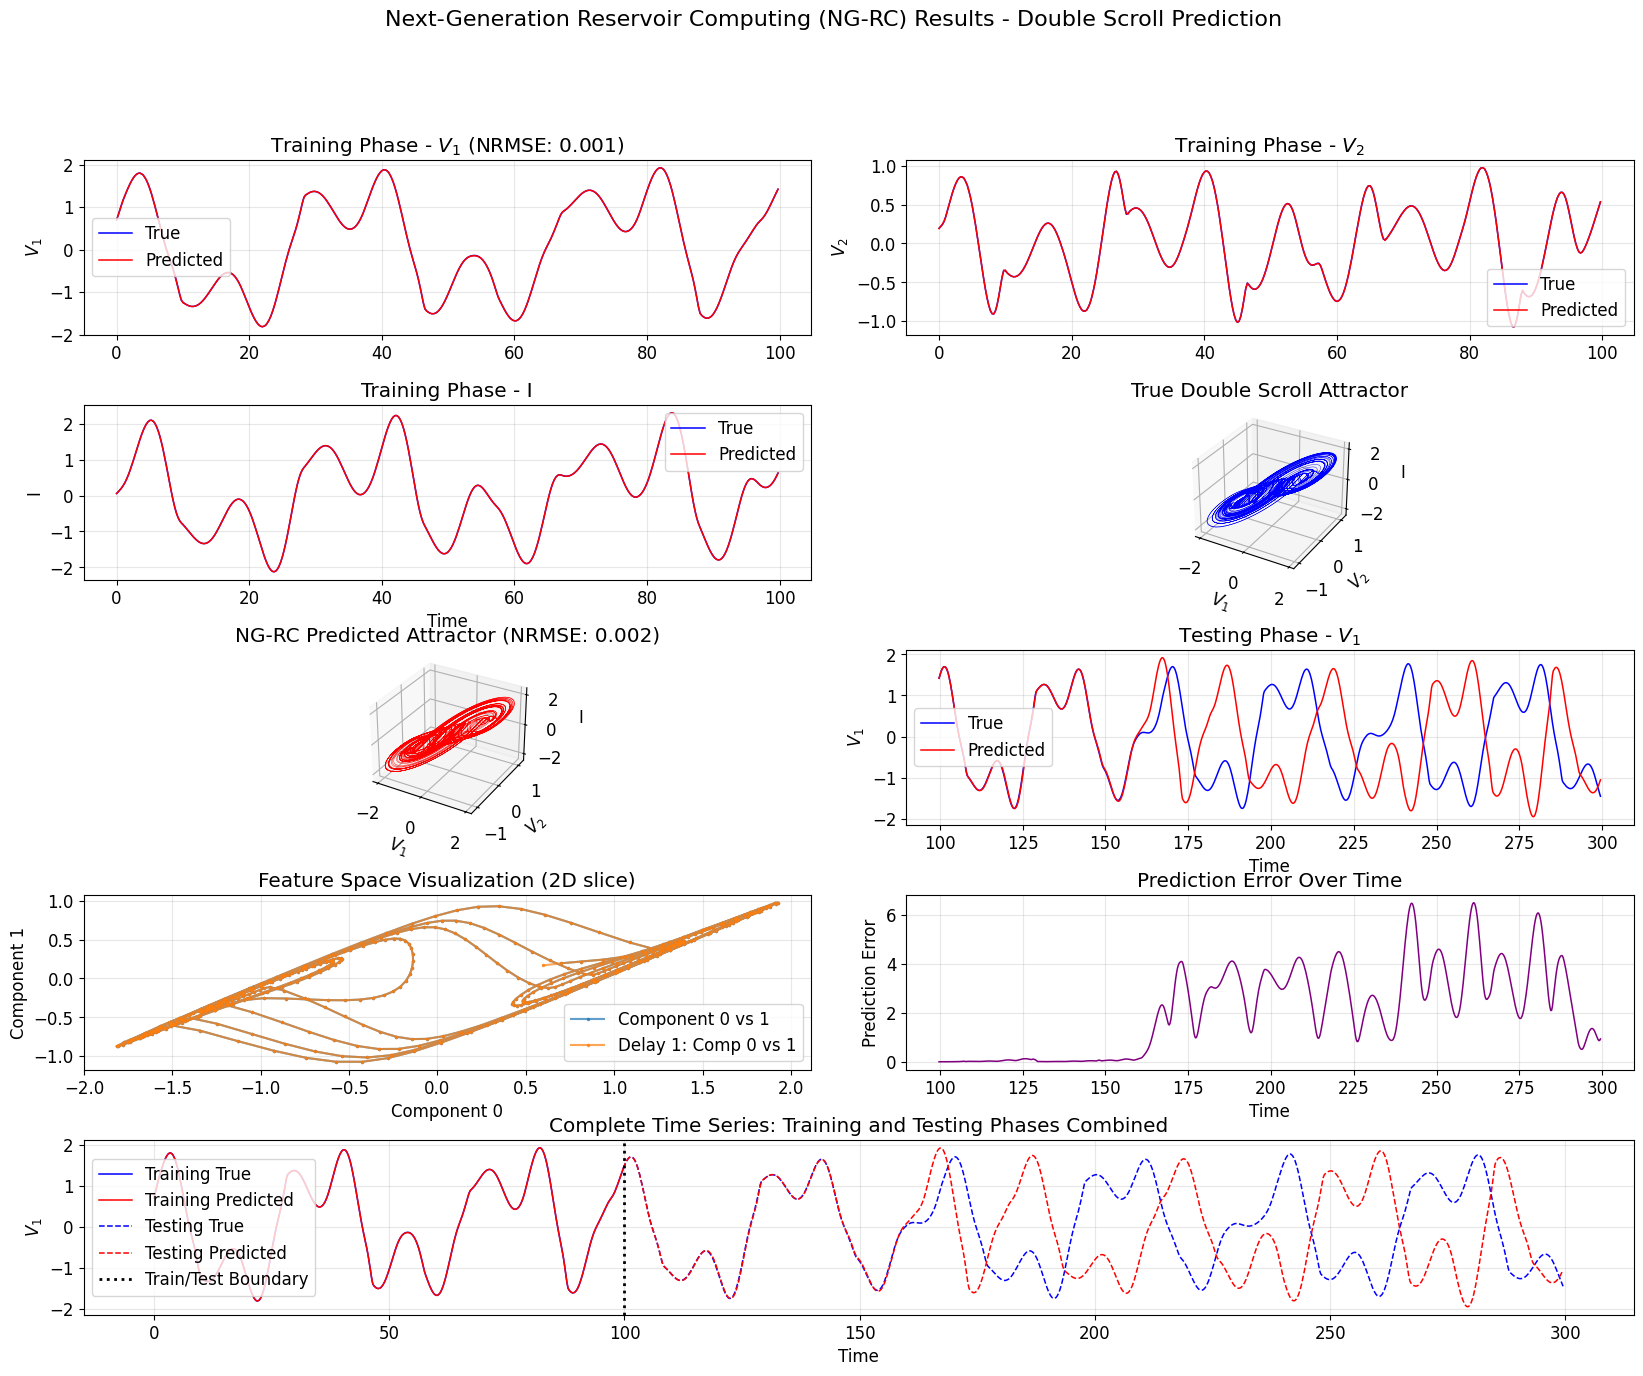


Running multiple trials for statistical analysis...
Starting NG-RC trial with warmup time: 1.0 units
Time discretization: dt=0.25, total points=3604
Feature vector dimensions: linear=6, nonlinear=56, total=62
Generating double scroll attractor...
Double scroll generated with variance: 2.5931
Creating feature vectors with delays...
Created 56 nonlinear features
Training output weights using ridge regression...
Training NRMSE: 0.0012
Starting prediction phase...
Test NRMSE (1 Lyapunov time): 0.0019
Analyzing fixed points...
Fixed point analysis complete
Starting NG-RC trial with warmup time: 101.0 units
Time discretization: dt=0.25, total points=4004
Feature vector dimensions: linear=6, nonlinear=56, total=62
Generating double scroll attractor...
Double scroll generated with variance: 2.6053
Creating feature vectors with delays...
Created 56 nonlinear features
Training output weights using ridge regression...
Training NRMSE: 0.0011
Starting prediction phase...
Test NRMSE (1 Lyapunov tim

In [13]:

"""
Created on Sat Feb 20 13:17:10 2021
Updated for Google Colab: Dec 2, 2025

NVAR with time delays for double-scroll forecasting, NRMSE, and fixed points.
This code demonstrates Reservoir Computing (specifically Next-Generation Reservoir Computing - NG-RC)
using Nonlinear Vector AutoRegression (NVAR) for chaotic time series prediction.

Reservoir Computing Explained:
- It's a machine learning method for time series prediction using dynamical systems
- Instead of training all network weights, only the "output layer" is trained
- The "reservoir" (or feature vector in NG-RC) processes input in a fixed, complex way
- NG-RC replaces the traditional reservoir with a fixed transformation of delayed inputs
- This makes it more predictable and mathematically tractable than traditional RC

Key Concepts:
1. Delay Embedding: Using past values of the signal to create a higher-dimensional representation
2. Polynomial Features: Creating nonlinear combinations of the delayed values
3. Ridge Regression: Training the output weights with L2 regularization
4. Fixed Point Analysis: Evaluating how well the RC preserves the system's fixed points

@author: Dan (Original)
@author: Google Colab Adaptation (2025)
"""

# Install required packages if needed
# In Colab, numpy, matplotlib, and scipy are pre-installed

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Reservoir Computing with Next-Generation Reservoir Computing (NG-RC)")
print("Using Nonlinear Vector AutoRegression (NVAR) for Chaotic Time Series Prediction")
print("="*70)

# do one trial of the NVAR, with the given warmup time
def do_nvar(warmup=1.):
    """
    Performs one trial of Next-Generation Reservoir Computing (NG-RC) using NVAR.

    The process:
    1. Generate a chaotic double-scroll attractor time series
    2. Create a feature vector using delayed values and polynomial features
    3. Train output weights using ridge regression
    4. Predict future values using the trained model
    5. Analyze fixed points of the system
    """
    print(f"Starting NG-RC trial with warmup time: {warmup} units")

    ##
    ## Parameters
    ##

    # time step
    dt = 0.25
    # units of time to train for
    traintime = 100.
    # units of time to test for
    testtime = 800.
    # Lyapunov time of double-scroll system
    lyaptime = 7.8125  # Henry Abarbanel finds Lyapunov exponent is 0.128
    # total time to run for
    maxtime = warmup + traintime + testtime

    # discrete-time versions of the times defined above
    warmup_pts = round(warmup/dt)
    traintime_pts = round(traintime/dt)
    warmtrain_pts = warmup_pts + traintime_pts
    testtime_pts = round(testtime/dt)
    maxtime_pts = round(maxtime/dt)
    lyaptime_pts = round(lyaptime/dt)

    print(f"Time discretization: dt={dt}, total points={maxtime_pts}")

    # input dimension (3D double scroll attractor)
    d = 3
    # number of time delay taps
    k = 2
    # size of the linear part of the feature vector
    dlin = k * d
    # size of the nonlinear part of feature vector (cubic polynomial terms)
    dnonlin = int(dlin * (dlin+1) * (dlin+2) / 6)  # For cubic: (n+d-1)! / (n!(d-1)!) where n=3
    # total size of feature vector: linear + nonlinear
    dtot = dlin + dnonlin

    print(f"Feature vector dimensions: linear={dlin}, nonlinear={dnonlin}, total={dtot}")

    # ridge parameter for regression
    ridge_param = 1.e-3

    # t values for whole evaluation time
    t_eval = np.linspace(0, maxtime, maxtime_pts+1)

    ##
    ## Double scroll attractor - a chaotic system
    ##

    # Parameters for the double scroll circuit
    r1 = 1.2
    r2 = 3.44
    r4 = 0.193
    alpha = 11.6
    ir = 2*2.25e-5  # the 2 is for the hyperbolic sine

    def doublescroll(t, y):
        """
        Defines the double scroll attractor differential equations.
        This is a chaotic electronic circuit model.
        y[0] = V1, y[1] = V2, y[2] = I
        """
        # y[0] = V1, y[1] = V2, y[2] = I
        dV = y[0] - y[1]  # V1-V2
        g = (dV/r2) + ir*np.sinh(alpha*dV)
        dy0 = (y[0]/r1) - g
        dy1 = g - y[2]
        dy2 = y[1] - r4*y[2]

        return [dy0, dy1, dy2]

    # Solve the differential equation to generate the chaotic time series
    print("Generating double scroll attractor...")
    doublescroll_soln = solve_ivp(
        doublescroll,
        (0, maxtime),
        [0.37926545, 0.058339, -0.08167691],  # Initial conditions on the attractor
        t_eval=t_eval,
        method='RK23'
    )

    # Calculate total variance for normalization
    total_var = np.var(doublescroll_soln.y[0,:]) + np.var(doublescroll_soln.y[1,:]) + np.var(doublescroll_soln.y[2,:])

    print(f"Double scroll generated with variance: {total_var:.4f}")

    ##
    ## NVAR (Next-Generation Reservoir Computing)
    ##

    # Create an array to hold the linear part of the feature vector
    # Each delay tap contains the 3D state vector
    x = np.zeros((dlin, maxtime_pts))

    print("Creating feature vectors with delays...")

    # Fill in the linear part of the feature vector for all times
    # This creates a delay embedding of the input signal
    for delay in range(k):
        for j in range(delay, maxtime_pts):
            # Each delay tap gets the full 3D state vector from 'delay' steps ago
            x[d*delay:d*(delay+1), j] = doublescroll_soln.y[:, j-delay]

    # Create an array to hold the full feature vector for training time
    out_train = np.zeros((dtot, traintime_pts))

    # Copy over the linear part (delayed values)
    out_train[0:dlin, :] = x[:, warmup_pts-1:warmtrain_pts-1]

    # Fill in the non-linear part (cubic polynomial terms)
    # This creates higher-order interactions between the delayed values
    cnt = 0
    for row in range(dlin):
        for column in range(row, dlin):
            for span in range(column, dlin):
                out_train[dlin+cnt, :] = (
                    x[row, warmup_pts-1:warmtrain_pts-1] *
                    x[column, warmup_pts-1:warmtrain_pts-1] *
                    x[span, warmup_pts-1:warmtrain_pts-1]
                )
                cnt += 1

    print(f"Created {cnt} nonlinear features")

    # Ridge regression: train W_out to map out_train to DScroll[t] - DScroll[t - 1]
    # This learns how to predict the next step from the feature vector
    print("Training output weights using ridge regression...")
    W_out = (
        (x[0:d, warmup_pts:warmtrain_pts] - x[0:d, warmup_pts-1:warmtrain_pts-1]) @
        out_train[:, :].T @
        np.linalg.pinv(out_train[:, :] @ out_train[:, :].T + ridge_param*np.identity(dtot))
    )

    # Apply W_out to the training feature vector to get the training output
    x_predict = x[0:d, warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:, 0:traintime_pts]

    # Calculate NRMSE between true double scroll and training output
    train_nrmse = np.sqrt(np.mean((x[0:d, warmup_pts:warmtrain_pts] - x_predict[:, :])**2) / total_var)

    print(f"Training NRMSE: {train_nrmse:.4f}")

    # Create a place to store feature vectors for prediction
    out_test = np.zeros(dtot)              # full feature vector
    x_test = np.zeros((dlin, testtime_pts))  # linear part

    # Copy over initial linear feature vector
    x_test[:, 0] = x[:, warmtrain_pts-1]

    print("Starting prediction phase...")

    # Do prediction - this is the core of reservoir computing
    # The system uses its previous state to form new feature vectors and predict
    for j in range(testtime_pts-1):
        # Copy linear part into whole feature vector
        out_test[0:dlin] = x_test[:, j]

        # Fill in the non-linear part (same transformation as training)
        cnt = 0
        for row in range(dlin):
            for column in range(row, dlin):
                for span in range(column, dlin):
                    out_test[dlin+cnt] = x_test[row, j] * x_test[column, j] * x_test[span, j]
                    cnt += 1

        # Update delay taps: shift old values back, new values go to front
        x_test[d:dlin, j+1] = x_test[0:(dlin-d), j]

        # Do a prediction: use learned weights to predict next state
        x_test[0:d, j+1] = x_test[0:d, j] + W_out @ out_test[:]

    # Calculate NRMSE between true double scroll and prediction for one Lyapunov time
    nrmse = np.sqrt(
        np.mean((x[0:d, warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1] -
                x_test[0:d, 0:lyaptime_pts])**2) / total_var
    )

    print(f"Test NRMSE (1 Lyapunov time): {nrmse:.4f}")

    # Find true fixed points of the double scroll system
    print("Analyzing fixed points...")
    fp_slope = (r1 / r2) - (r4 / r2) - 1
    fp_sinhx = alpha * (1 - r4 / r1)
    fp_sinhy = r1 * ir
    V1_fp = fsolve(lambda V1: fp_slope * V1 + fp_sinhy * np.sinh(fp_sinhx * V1), 1.05)

    # Set up true fixed points
    t_fp0 = np.zeros(d)
    t_fp1 = np.zeros(d)
    t_fp2 = np.zeros(d)
    # True fixed point 1 - fixing the deprecation warning
    t_fp1[0] = V1_fp[0] if isinstance(V1_fp, np.ndarray) else V1_fp
    t_fp1[1] = r4 * t_fp1[0] / r1
    t_fp1[2] = t_fp1[0] / r1
    # True fixed point 2 (symmetric)
    t_fp2[0] = -t_fp1[0]
    t_fp2[1] = -t_fp1[1]
    t_fp2[2] = -t_fp1[2]

    # Function to evaluate fixed points in the RC model
    def func(p_fp):
        """
        Evaluates how a candidate fixed point behaves in the RC model.
        Returns the change in the point after one step.
        """
        # Create a trial input feature vector
        out_vec = np.ones(dtot)
        # Fill in the linear part - all delay taps have the same value (fixed point)
        for ii in range(k):
            out_vec[ii*d:(ii+1)*d] = p_fp[0:d]
        # Fill in the nonlinear part
        cnt = 0
        for row in range(dlin):
            for column in range(row, dlin):
                for span in range(column, dlin):
                    out_vec[dlin+cnt] = out_vec[row] * out_vec[column] * out_vec[span]
                    cnt += 1
        return W_out @ out_vec

    # Solve for the predicted fixed points
    p_fp1 = fsolve(func, t_fp1)
    n_fp1_diff = np.sqrt(np.sum((t_fp1 - p_fp1)**2) / total_var)
    p_fp1_norm = (t_fp1 - p_fp1) / np.sqrt(total_var)

    p_fp2 = fsolve(func, t_fp2)
    n_fp2_diff = np.sqrt(np.sum((t_fp2 - p_fp2)**2) / total_var)
    p_fp2_norm = (t_fp2 - p_fp2) / np.sqrt(total_var)

    p_fp0 = fsolve(func, t_fp0)
    n_fp0_diff = np.sqrt(np.sum((t_fp0 - p_fp0)**2) / total_var)
    p_fp0_norm = (t_fp0 - p_fp0) / np.sqrt(total_var)

    print("Fixed point analysis complete")

    # Return all our local variables we've defined
    return locals()

def visualize_results(dt, x, warmtrain_pts, maxtime_pts, t_eval, warmup_pts, warmup,
                     x_predict, x_test, train_nrmse, nrmse, **extra):
    """
    Creates comprehensive visualizations of the NG-RC results
    """
    print("\nCreating visualizations...")

    # Amount of time to plot prediction for
    plottime = 200.
    plottime_pts = round(plottime/dt)

    t_linewidth = 1.1
    a_linewidth = 0.3
    plt.rcParams.update({'font.size': 12})

    # Create figure with subplots for comprehensive view
    fig = plt.figure(figsize=(20, 15))

    # Define grid positions for subplots
    gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.3)

    # Plot 1: Training phase V1
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x[0, warmup_pts:warmtrain_pts],
             linewidth=t_linewidth, label='True', color='blue')
    ax1.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x_predict[0, :],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax1.set_ylabel('$V_1$')
    ax1.set_title(f'Training Phase - $V_1$ (NRMSE: {train_nrmse:.3f})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Training phase V2
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax2.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x[1, warmup_pts:warmtrain_pts],
             linewidth=t_linewidth, label='True', color='blue')
    ax2.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x_predict[1, :],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax2.set_ylabel('$V_2$')
    ax2.set_title('Training Phase - $V_2$')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Training phase I
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax3.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x[2, warmup_pts:warmtrain_pts],
             linewidth=t_linewidth, label='True', color='blue')
    ax3.plot(t_eval[warmup_pts:warmtrain_pts] - warmup, x_predict[2, :],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax3.set_ylabel('I')
    ax3.set_xlabel('Time')
    ax3.set_title('Training Phase - I')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Phase space - True attractor
    ax4 = fig.add_subplot(gs[1, 2:4], projection='3d')
    ax4.plot(x[0, warmtrain_pts:maxtime_pts],
             x[1, warmtrain_pts:maxtime_pts],
             x[2, warmtrain_pts:maxtime_pts],
             linewidth=a_linewidth, color='blue', label='True')
    ax4.set_title('True Double Scroll Attractor')
    ax4.set_xlabel('$V_1$')
    ax4.set_ylabel('$V_2$')
    ax4.set_zlabel('I')

    # Plot 5: Phase space - Predicted attractor
    ax5 = fig.add_subplot(gs[2, 0:2], projection='3d')
    ax5.plot(x_test[0, :], x_test[1, :], x_test[2, :],
             linewidth=a_linewidth, color='red', label='Predicted')
    ax5.set_title(f'NG-RC Predicted Attractor (NRMSE: {nrmse:.3f})')
    ax5.set_xlabel('$V_1$')
    ax5.set_ylabel('$V_2$')
    ax5.set_zlabel('I')

    # Plot 6: Testing phase V1
    ax6 = fig.add_subplot(gs[2, 2:4])
    start_idx = warmtrain_pts-1
    end_idx = min(warmtrain_pts + plottime_pts - 1, x.shape[1])
    plot_len = end_idx - start_idx
    ax6.plot(t_eval[start_idx:end_idx] - warmup,
             x[0, start_idx:end_idx],
             linewidth=t_linewidth, label='True', color='blue')
    ax6.plot(t_eval[start_idx:end_idx] - warmup,
             x_test[0, :plot_len],
             linewidth=t_linewidth, label='Predicted', color='red')
    ax6.set_ylabel('$V_1$')
    ax6.set_xlabel('Time')
    ax6.set_title('Testing Phase - $V_1$')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # Plot 7: Feature space visualization (first few dimensions)
    ax7 = fig.add_subplot(gs[3, 0:2])
    # Show a small section of feature vectors - fix indexing issue
    feature_section = min(500, x.shape[1] - warmup_pts)
    ax7.plot(x[0, warmup_pts:warmup_pts+feature_section],
             x[1, warmup_pts:warmup_pts+feature_section],
             '.-', markersize=3, alpha=0.7, label='Component 0 vs 1')
    # Only plot delay 1 if we have enough dimensions (d=3, k=2 so dlin=6)
    if x.shape[0] > d:  # If we have more than 3 dimensions (meaning we have delays)
        ax7.plot(x[3, warmup_pts:warmup_pts+feature_section],
                 x[4, warmup_pts:warmup_pts+feature_section],
                 '.-', markersize=3, alpha=0.7, label='Delay 1: Comp 0 vs 1')
    ax7.set_xlabel('Component 0')
    ax7.set_ylabel('Component 1')
    ax7.set_title('Feature Space Visualization (2D slice)')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # Plot 8: Error over time during testing
    ax8 = fig.add_subplot(gs[3, 2:4])
    test_errors = np.sqrt(np.sum((x[0:d, warmtrain_pts-1:warmtrain_pts+plottime_pts-1] -
                                  x_test[0:d, 0:plottime_pts])**2, axis=0))
    ax8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1] - warmup,
             test_errors, linewidth=t_linewidth, color='purple')
    ax8.set_xlabel('Time')
    ax8.set_ylabel('Prediction Error')
    ax8.set_title('Prediction Error Over Time')
    ax8.grid(True, alpha=0.3)

    # NEW PLOT: Time series showing training and testing together
    ax9 = fig.add_subplot(gs[4, :])
    # Training phase
    train_start = warmup_pts
    train_end = warmtrain_pts
    ax9.plot(t_eval[train_start:train_end] - warmup,
             x[0, train_start:train_end],
             linewidth=t_linewidth, label='Training True', color='blue')
    ax9.plot(t_eval[train_start:train_end] - warmup,
             x_predict[0, :],
             linewidth=t_linewidth, label='Training Predicted', color='red')

    # Testing phase
    test_start = warmtrain_pts-1
    test_end = min(warmtrain_pts + plottime_pts - 1, x.shape[1])
    test_len = test_end - test_start
    ax9.plot(t_eval[test_start:test_end] - warmup,
             x[0, test_start:test_end],
             linewidth=t_linewidth, label='Testing True', color='blue', linestyle='--')
    ax9.plot(t_eval[test_start:test_end] - warmup,
             x_test[0, :test_len],
             linewidth=t_linewidth, label='Testing Predicted', color='red', linestyle='--')

    # Add vertical line to indicate where testing starts
    ax9.axvline(x=t_eval[warmtrain_pts] - warmup, color='black', linestyle=':',
                linewidth=2, label='Train/Test Boundary')

    ax9.set_xlabel('Time')
    ax9.set_ylabel('$V_1$')
    ax9.set_title('Complete Time Series: Training and Testing Phases Combined')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    plt.suptitle('Next-Generation Reservoir Computing (NG-RC) Results - Double Scroll Prediction',
                 fontsize=16, y=0.98)
    plt.show()

def explain_reservoir_computing():
    """
    Provides an explanation of Reservoir Computing and NG-RC
    """
    print("\n" + "="*70)
    print("RESERVOIR COMPUTING & NEXT-GENERATION RESERVOIR COMPUTING (NG-RC)")
    print("="*70)

    print("\nWhat is Reservoir Computing?")
    print("-" * 40)
    print("• A machine learning technique for processing temporal data")
    print("• Uses a fixed, high-dimensional dynamical system (the 'reservoir')")
    print("• Only the output layer is trained, making it efficient")
    print("• Excels at tasks involving time series prediction and pattern recognition")

    print("\nTraditional Reservoir Computing:")
    print("-" * 40)
    print("• Uses a recurrent neural network as the reservoir")
    print("• Requires careful tuning of reservoir parameters")
    print("• Can be difficult to analyze mathematically")

    print("\nNext-Generation Reservoir Computing (NG-RC):")
    print("-" * 40)
    print("• Replaces the reservoir with delay coordinates and polynomial features")
    print("• More predictable and mathematically tractable")
    print("• Uses time-delayed inputs as the 'reservoir'")
    print("• Creates nonlinear features from the delayed inputs")

    print("\nHow NG-RC Works in This Code:")
    print("-" * 40)
    print("1. DELAY EMBEDDING: Creates feature vector using past values:")
    print("   [x(t), x(t-τ), x(t-2τ), ...] where x is the 3D state vector")
    print("2. POLYNOMIAL FEATURES: Creates nonlinear combinations:")
    print("   [linear terms, quadratic terms, cubic terms, ...]")
    print("3. TRAINING: Uses ridge regression to learn output weights")
    print("4. PREDICTION: Uses learned weights to forecast future states")
    print("5. ANALYSIS: Compares predicted vs true fixed points of the system")

    print("\nWhy Use This Approach?")
    print("-" * 40)
    print("• Handles chaotic systems with long-term memory")
    print("• Preserves important dynamical properties (fixed points)")
    print("• Computationally efficient compared to training full RNNs")
    print("• Good for forecasting complex, nonlinear time series")

    print("\nKey Parameters in This Implementation:")
    print("-" * 40)
    print(f"• Input dimension (d): {3} (3D double scroll attractor)")
    print(f"• Delay taps (k): {2} (using current and 1 past value)")
    print(f"• Polynomial degree: 3 (cubic features)")
    print(f"• Total features: {3*2} linear + {int(6*7*8/6)} nonlinear = {6 + int(6*7*8/6)} total")
    print(f"• Ridge parameter: {1.e-3} (controls regularization)")

# Run explanation
explain_reservoir_computing()

# Run one NVAR to plot the forecast
print("\nRunning NG-RC prediction...")
start_time = time.time()
results = do_nvar()
end_time = time.time()
print(f"NG-RC completed in {end_time - start_time:.2f} seconds")

# Visualize the results
visualize_results(**results)

# Run multiple trials to calculate statistics
print("\nRunning multiple trials for statistical analysis...")
npts = 5  # Reduced for demo purposes in Colab
train_nrmse_v = np.zeros(npts)
test_nrmse_v = np.zeros(npts)
n_fp1_diff_v = np.zeros(npts)
n_fp2_diff_v = np.zeros(npts)
n_fp0_diff_v = np.zeros(npts)
p_fp1_norm_v = np.zeros((npts, 3))
p_fp2_norm_v = np.zeros((npts, 3))
p_fp0_norm_v = np.zeros((npts, 3))

for i in range(npts):
    r = do_nvar(warmup=1. + 100. * i)
    train_nrmse_v[i] = r['train_nrmse']
    test_nrmse_v[i] = r['nrmse']
    n_fp1_diff_v[i] = r['n_fp1_diff']
    n_fp2_diff_v[i] = r['n_fp2_diff']
    n_fp0_diff_v[i] = r['n_fp0_diff']
    p_fp1_norm_v[i] = r['p_fp1_norm']
    p_fp2_norm_v[i] = r['p_fp2_norm']
    p_fp0_norm_v[i] = r['p_fp0_norm']

# Print summary statistics
print('\n' + '='*50)
print('SUMMARY STATISTICS OVER', npts, 'TRIALS')
print('='*50)
print(f'Ridge regression parameter: {r["ridge_param"]}')
print(f'Mean Training NRMSE: {np.mean(train_nrmse_v):.4f} ± {np.std(train_nrmse_v)/np.sqrt(npts):.4f}')
print(f'Mean Test NRMSE: {np.mean(test_nrmse_v):.4f} ± {np.std(test_nrmse_v)/np.sqrt(npts):.4f}')

print(f'\nFixed Point Analysis:')
print(f'Mean |True - Predicted| for FP1: {np.mean(n_fp1_diff_v):.4f} ± {np.std(n_fp1_diff_v)/np.sqrt(npts):.4f}')
print(f'Mean |True - Predicted| for FP2: {np.mean(n_fp2_diff_v):.4f} ± {np.std(n_fp2_diff_v)/np.sqrt(npts):.4f}')
print(f'Mean |True - Predicted| for FP0: {np.mean(n_fp0_diff_v):.4f} ± {np.std(n_fp0_diff_v)/np.sqrt(npts):.4f}')

print(f'\nComponent-wise Fixed Point Differences:')
print(f'FP1: {np.mean(p_fp1_norm_v, axis=0)} ± {np.std(p_fp1_norm_v, axis=0) / np.sqrt(npts)}')
print(f'FP2: {np.mean(p_fp2_norm_v, axis=0)} ± {np.std(p_fp2_norm_v, axis=0) / np.sqrt(npts)}')
print(f'FP0: {np.mean(p_fp0_norm_v, axis=0)} ± {np.std(p_fp0_norm_v, axis=0) / np.sqrt(npts)}')

print("\nNG-RC Analysis Complete!")
print("This implementation demonstrates how Reservoir Computing can predict chaotic systems")
print("while preserving important dynamical properties like fixed points.")
